# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

### From the plot, I observed....
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values.

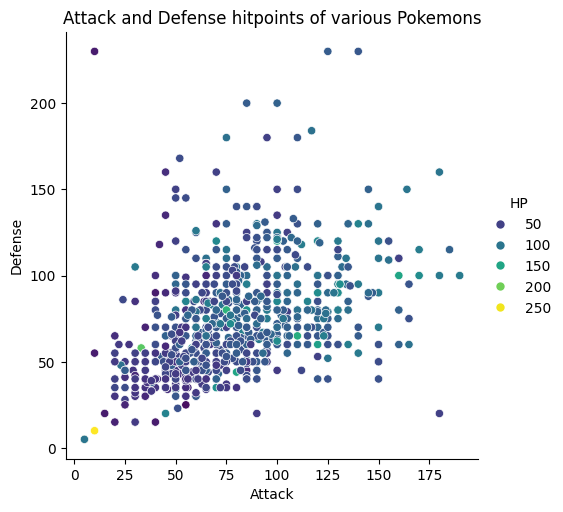

In [5]:
# Your code here . . .
pokemons = pd.read_csv(fp)
sns.relplot(
    data = pokemons,
    x = "Attack",
    y = "Defense",
    hue = "HP",
    palette="viridis"
)

plt.title("Attack and Defense hitpoints of various Pokemons");

There seems to be a positive correlation between attack and defense values of the Pokemon. It also seems that higher defense and attack combinations also have higher HP.

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

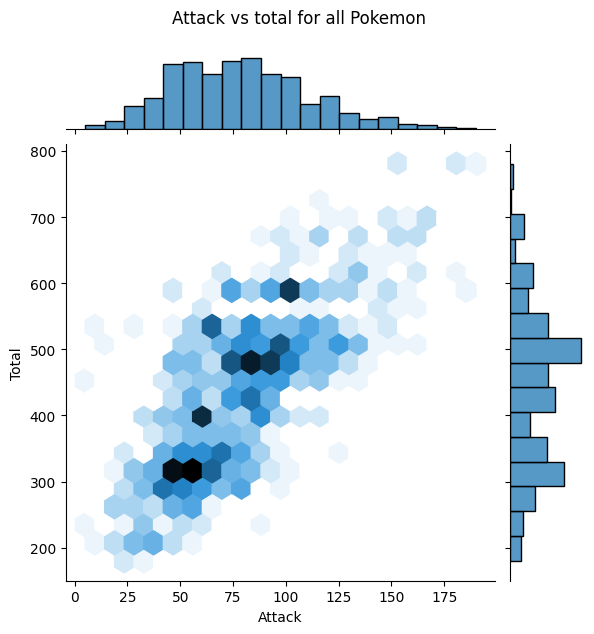

In [13]:
# Your code here . . .
hexPlot = sns.jointplot(
    data = pokemons,
    x = "Attack",
    y = "Total",
    kind = "hex",
    gridsize = 20
)
hexPlot.fig.suptitle("Attack vs total for all Pokemon", y = 1.05);

The hexplot also shows the density of the data. The darker hexagons are more dense and the lighter hexagons are less data dense.

From the plot, I observed.... there is a positive correlation between Attack and Total with more data in the lower left quadrant.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

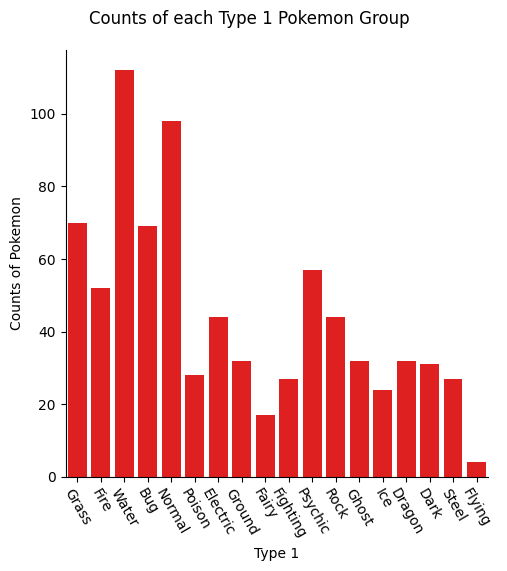

In [40]:
# Your code here . . .
g = sns.catplot(
    x = 'Type 1',
    data = pokemons,
    kind = 'count',
    color = 'red'
).set_axis_labels('Type 1', 'Counts of Pokemon'); # I switched the labels because they made more sense this way.
g.set_xticklabels(rotation=300);
g.fig.suptitle("Counts of each Type 1 Pokemon Group", y = 1.05);

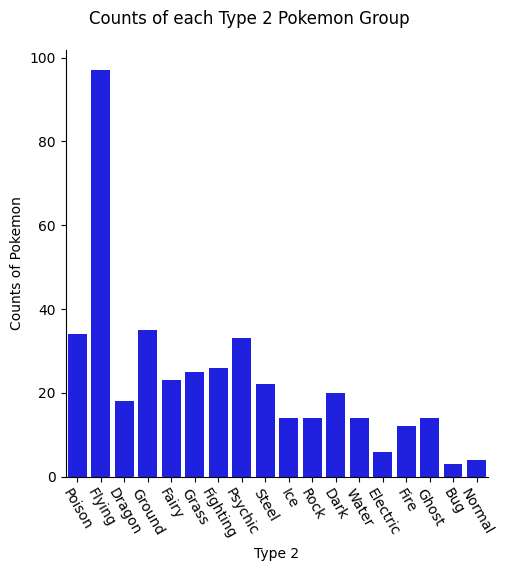

In [39]:
g = sns.catplot(
    x = 'Type 2',
    data = pokemons,
    kind = 'count',
    color = 'blue'
).set_axis_labels('Type 2', 'Counts of Pokemon'); # I switched the labels because they made more sense this way.
g.set_xticklabels(rotation=300);
g.fig.suptitle("Counts of each Type 2 Pokemon Group", y = 1.05);

The most common Type 1 Pokemon is the Water Pokemon and the most common Type 2 Pokemon is the Flying Pokemon. The most rare Type 1 Pokemon is the Flying Pokemon and the most rare Type 2 Pokemon is the Bug Pokemon.

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

Your question(s) . . .

Are there more Legendary or Non-Legendary Pokemon? How do they relate to each other? There are very few Legendary Pokemon compared to Non-Legendary Pokemon. Perhaps roughly 8 times less.

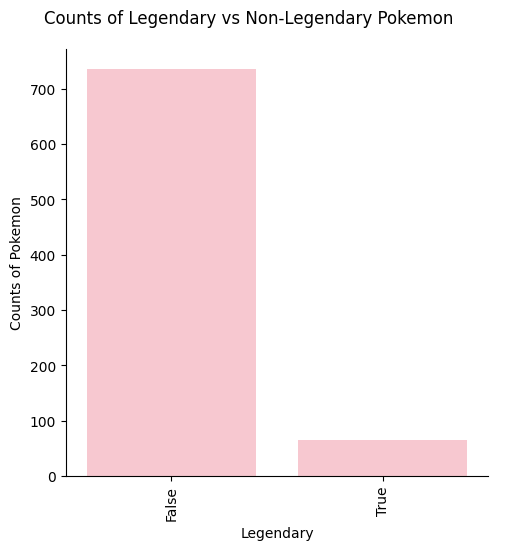

In [38]:
# Your code here . . .
g = sns.catplot(
    x = 'Legendary',
    data = pokemons,
    kind = 'count',
    color = 'pink'
).set_axis_labels('Legendary', 'Counts of Pokemon');
g.set_xticklabels(rotation=90);
g.fig.suptitle("Counts of Legendary vs Non-Legendary Pokemon", y = 1.05);

Does the generation a Pokemon was released have an effect on its speed? Also, is there a correlation to HP?
No, it does not look like the Pokemon generation release correlates to a certain speed. It also does not seem like there is any correlation with HP.

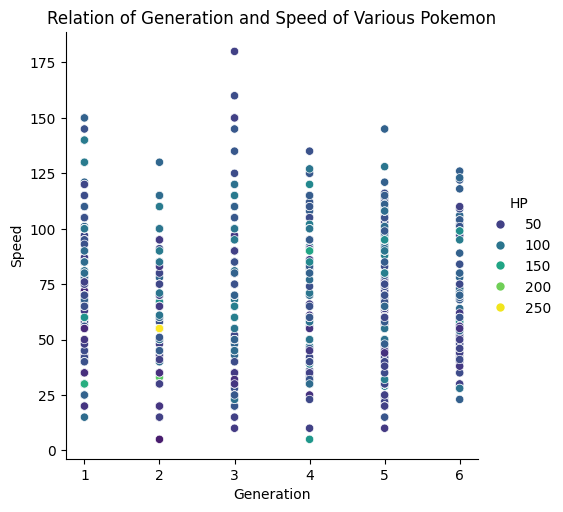

In [32]:
sns.relplot(
    data = pokemons,
    x = "Generation",
    y = "Speed",
    hue = "HP",
    palette="viridis"
)

plt.title("Relation of Generation and Speed of Various Pokemon");

Is there a correlation between Special Attack and Attack? (I do not know Pokemon well).
There appears to be the slightest positive correlation between Special Attack and Attack.

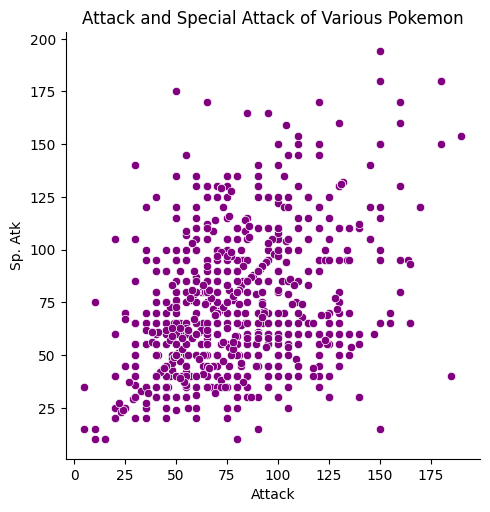

In [35]:
sns.relplot(
    data = pokemons,
    x = "Attack",
    y = "Sp. Atk",
    color = "Purple"
)

plt.title("Attack and Special Attack of Various Pokemon");